<a href="https://colab.research.google.com/github/afullhart/SantaRita/blob/main/Widgets/NRI_Sims.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%reset -f

# High Bare Ground Functions and Widget

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon, LineString
from shapely.ops import unary_union
import ipywidgets as widgets
from IPython.display import display, clear_output

# ==========================================
# Geometry Generation Functions
# ==========================================
def create_irregular_shrub(center_x, center_y, base_radius, num_points=12):
    """Generates an irregular polygon to represent a shrub."""
    angles = np.linspace(0, 2 * np.pi, num_points, endpoint=False)
    points = []
    for angle in angles:
        # Perturb the radius by +/- 40% to make it irregular
        r = base_radius * np.random.uniform(0.6, 1.4)
        points.append((center_x + r * np.cos(angle), center_y + r * np.sin(angle)))
    return Polygon(points)

def generate_random_shrubs(num_shrubs=60, plot_radius=55): # UPDATED: 60 shrubs
    """Generates a list of randomly placed shrub polygons within the plot."""
    shrubs = []

    # UPDATED: Max shrub radius is now 5m
    max_shrub_radius = 5.0
    generation_radius = plot_radius + max_shrub_radius

    for _ in range(num_shrubs):
        # UPDATED: Random radius between 1m and 5m (Average = 3m)
        radius = np.random.uniform(1.0, 5.0)

        # Uniform distribution up to 60m
        r = generation_radius * np.sqrt(np.random.uniform(0, 1))
        theta = np.random.uniform(0, 2 * np.pi)

        x = r * np.cos(theta)
        y = r * np.sin(theta)
        shrubs.append(create_irregular_shrub(x, y, radius))
    return shrubs

def get_nri_spokes(hub_radius=5, plot_radius=55):
    """Generates the 3 NRI transect lines at 0, 120, and 240 degrees."""
    angles = [0, 120, 240]
    spokes = []
    for a in angles:
        rad = np.radians(a)
        x1, y1 = hub_radius * np.cos(rad), hub_radius * np.sin(rad)
        x2, y2 = plot_radius * np.cos(rad), plot_radius * np.sin(rad)
        spokes.append(LineString([(x1, y1), (x2, y2)]))
    return spokes

# ==========================================
# Main Simulation Class
# ==========================================
class NRISimulation:
    def __init__(self):
        self.plot_radius = 55
        self.hub_radius = 5
        self.plot_circle = Point(0, 0).buffer(self.plot_radius)
        self.spokes = get_nri_spokes(self.hub_radius, self.plot_radius)
        self.total_transect_length = 3 * (self.plot_radius - self.hub_radius) # 150m
        self.shrubs = []
        self.shrub_union = None

        # Output widget for matplotlib to prevent cell output spam
        self.out = widgets.Output()

        # Setup UI FIRST so the dropdown attribute exists before plotting
        self.setup_ui()

        # Generate initial data (this calls update_plot internally)
        self.generate_new_shapes()

    def generate_new_shapes(self, b=None):
        """Creates entirely new shrub geometries and positions."""
        self.shrubs = generate_random_shrubs(60, self.plot_radius) # UPDATED: 60 shrubs
        self.shrub_union = unary_union(self.shrubs)
        self.update_plot()

    def randomize_positions(self, b=None):
        """Moves existing shrubs to new locations."""
        new_shrubs = []

        # UPDATED: Expand generation area by max shrub radius (5.0m)
        generation_radius = self.plot_radius + 5.0

        for shrub in self.shrubs:
            # Calculate current centroid
            cx, cy = shrub.centroid.x, shrub.centroid.y

            # Generate new random position (Uniform distribution up to 60m)
            r = generation_radius * np.sqrt(np.random.uniform(0, 1))
            theta = np.random.uniform(0, 2 * np.pi)

            new_cx, new_cy = r * np.cos(theta), r * np.sin(theta)

            # Translate polygon
            from shapely.affinity import translate
            new_shrub = translate(shrub, xoff=(new_cx - cx), yoff=(new_cy - cy))
            new_shrubs.append(new_shrub)

        self.shrubs = new_shrubs
        self.shrub_union = unary_union(self.shrubs)
        self.update_plot()

    def setup_ui(self):
        self.protocol_dropdown = widgets.Dropdown(
            options=[
                ('0m (Continuous Line)', 0.0),
                ('0.25m (Point Intercept)', 0.25),
                ('0.50m (Point Intercept)', 0.50),
                ('1.00m (Point Intercept)', 1.00),
                ('2.00m (Point Intercept)', 2.00)
            ],
            value=0.0,
            description='Protocol:'
        )
        self.protocol_dropdown.observe(lambda change: self.update_plot() if change['name'] == 'value' else None)

        self.btn_randomize = widgets.Button(description="Randomize Positions", button_style='info')
        self.btn_randomize.on_click(self.randomize_positions)

        self.btn_new_shapes = widgets.Button(description="Generate New Shrubs", button_style='warning')
        self.btn_new_shapes.on_click(self.generate_new_shapes)

        controls = widgets.HBox([self.protocol_dropdown, self.btn_randomize, self.btn_new_shapes])
        display(widgets.VBox([controls, self.out]))

    def update_plot(self):
        with self.out:
            clear_output(wait=True)
            interval = self.protocol_dropdown.value

            # 1. Calculate True Bare Ground
            # Clip shrubs to plot boundary just in case they stick out (Handles spill-over!)
            shrubs_in_plot = self.shrub_union.intersection(self.plot_circle)
            true_bare_area = self.plot_circle.area - shrubs_in_plot.area
            true_bg_pct = (true_bare_area / self.plot_circle.area) * 100

            # 2. Plotting setup
            fig, ax = plt.subplots(figsize=(5, 5))
            ax.set_aspect('equal')
            ax.set_facecolor('#f0f0f0')
            ax.axis('off')

            # Draw plot boundary and hub
            plot_patch = plt.Circle((0, 0), self.plot_radius, color='white', ec='black', lw=2)
            hub_patch = plt.Circle((0, 0), self.hub_radius, color='#e0e0e0', ec='black', lw=1, ls='--')
            ax.add_patch(plot_patch)
            ax.add_patch(hub_patch)

            # Draw Shrubs (Including those just outside the boundary)
            if self.shrub_union.geom_type == 'Polygon':
                geoms = [self.shrub_union]
            else:
                geoms = self.shrub_union.geoms

            for geom in geoms:
                x, y = geom.exterior.xy
                ax.fill(x, y, alpha=0.5, fc='forestgreen', ec='darkgreen', lw=1.5)

            # 3. Calculate Sampled Bare Ground & Draw Sampling Tools
            sampled_bg_pct = 0

            if interval == 0.0: # Continuous Line Intercept
                total_intercept = 0
                for spoke in self.spokes:
                    # Draw base spoke
                    x, y = spoke.xy
                    ax.plot(x, y, color='gray', lw=2, zorder=3)

                    # Intersect with shrubs
                    intersection = spoke.intersection(self.shrub_union)
                    total_intercept += intersection.length

                    # Highlight intersections
                    if not intersection.is_empty:
                        if intersection.geom_type == 'LineString':
                            ix, iy = intersection.xy
                            ax.plot(ix, iy, color='red', lw=3, zorder=4)
                        elif intersection.geom_type == 'MultiLineString':
                            for line in intersection.geoms:
                                ix, iy = line.xy
                                ax.plot(ix, iy, color='red', lw=3, zorder=4)

                sampled_bg_pct = (1 - (total_intercept / self.total_transect_length)) * 100

            else: # Point Intercept
                total_points = 0
                bare_points = 0

                # Draw faint lines for context
                for spoke in self.spokes:
                    x, y = spoke.xy
                    ax.plot(x, y, color='lightgray', lw=1, zorder=2)

                # Generate and test points
                for spoke in self.spokes:
                    # spoke length is 50m
                    for d in np.arange(0, 50.001, interval):
                        pt = spoke.interpolate(d)
                        total_points += 1

                        if self.shrub_union.contains(pt):
                            ax.plot(pt.x, pt.y, 'ro', markersize=4, zorder=4) # Shrub hit
                        else:
                            ax.plot(pt.x, pt.y, 'ko', markersize=3, zorder=4) # Bare ground hit
                            bare_points += 1

                sampled_bg_pct = (bare_points / total_points) * 100 if total_points > 0 else 0

            # 4. Display Metrics
            error = sampled_bg_pct - true_bg_pct

            title_text = (
                f"True Bare Ground: {true_bg_pct:.2f}%\n"
                f"Sampled Bare Ground: {sampled_bg_pct:.2f}%\n"
            )

            # Color code the error text based on severity
            color = 'black'
            if abs(error) > 5: color = 'darkorange'
            if abs(error) > 10: color = 'red'

            plt.title(title_text, fontsize=14, pad=15)
            plt.figtext(0.5, 0.05, f"Error (Bias): {error:+.2f}%", ha="center", fontsize=16, fontweight='bold', color=color)

            plt.xlim(-70, 70) # Expanded view to see spill-over shrubs
            plt.ylim(-70, 70)
            plt.tight_layout()
            plt.show()

# Run the simulation
simulation = NRISimulation()


### All intervals figure

--- STATISTICAL SUMMARY (HIGH BARE GROUND) ---
Protocol: 0m (Continuous Line)
  Mean Bias: +0.0230% | MAE: 5.4244% | Std Dev: 6.7235%

Protocol: 0.25m (Point Intercept)
  Mean Bias: +0.0205% | MAE: 5.4103% | Std Dev: 6.7046%

Protocol: 0.50m (Point Intercept)
  Mean Bias: +0.0164% | MAE: 5.3904% | Std Dev: 6.6882%

Protocol: 1.00m (Point Intercept)
  Mean Bias: +0.0119% | MAE: 5.3580% | Std Dev: 6.6417%

Protocol: 2.00m (Point Intercept)
  Mean Bias: +0.0013% | MAE: 5.3342% | Std Dev: 6.6560%



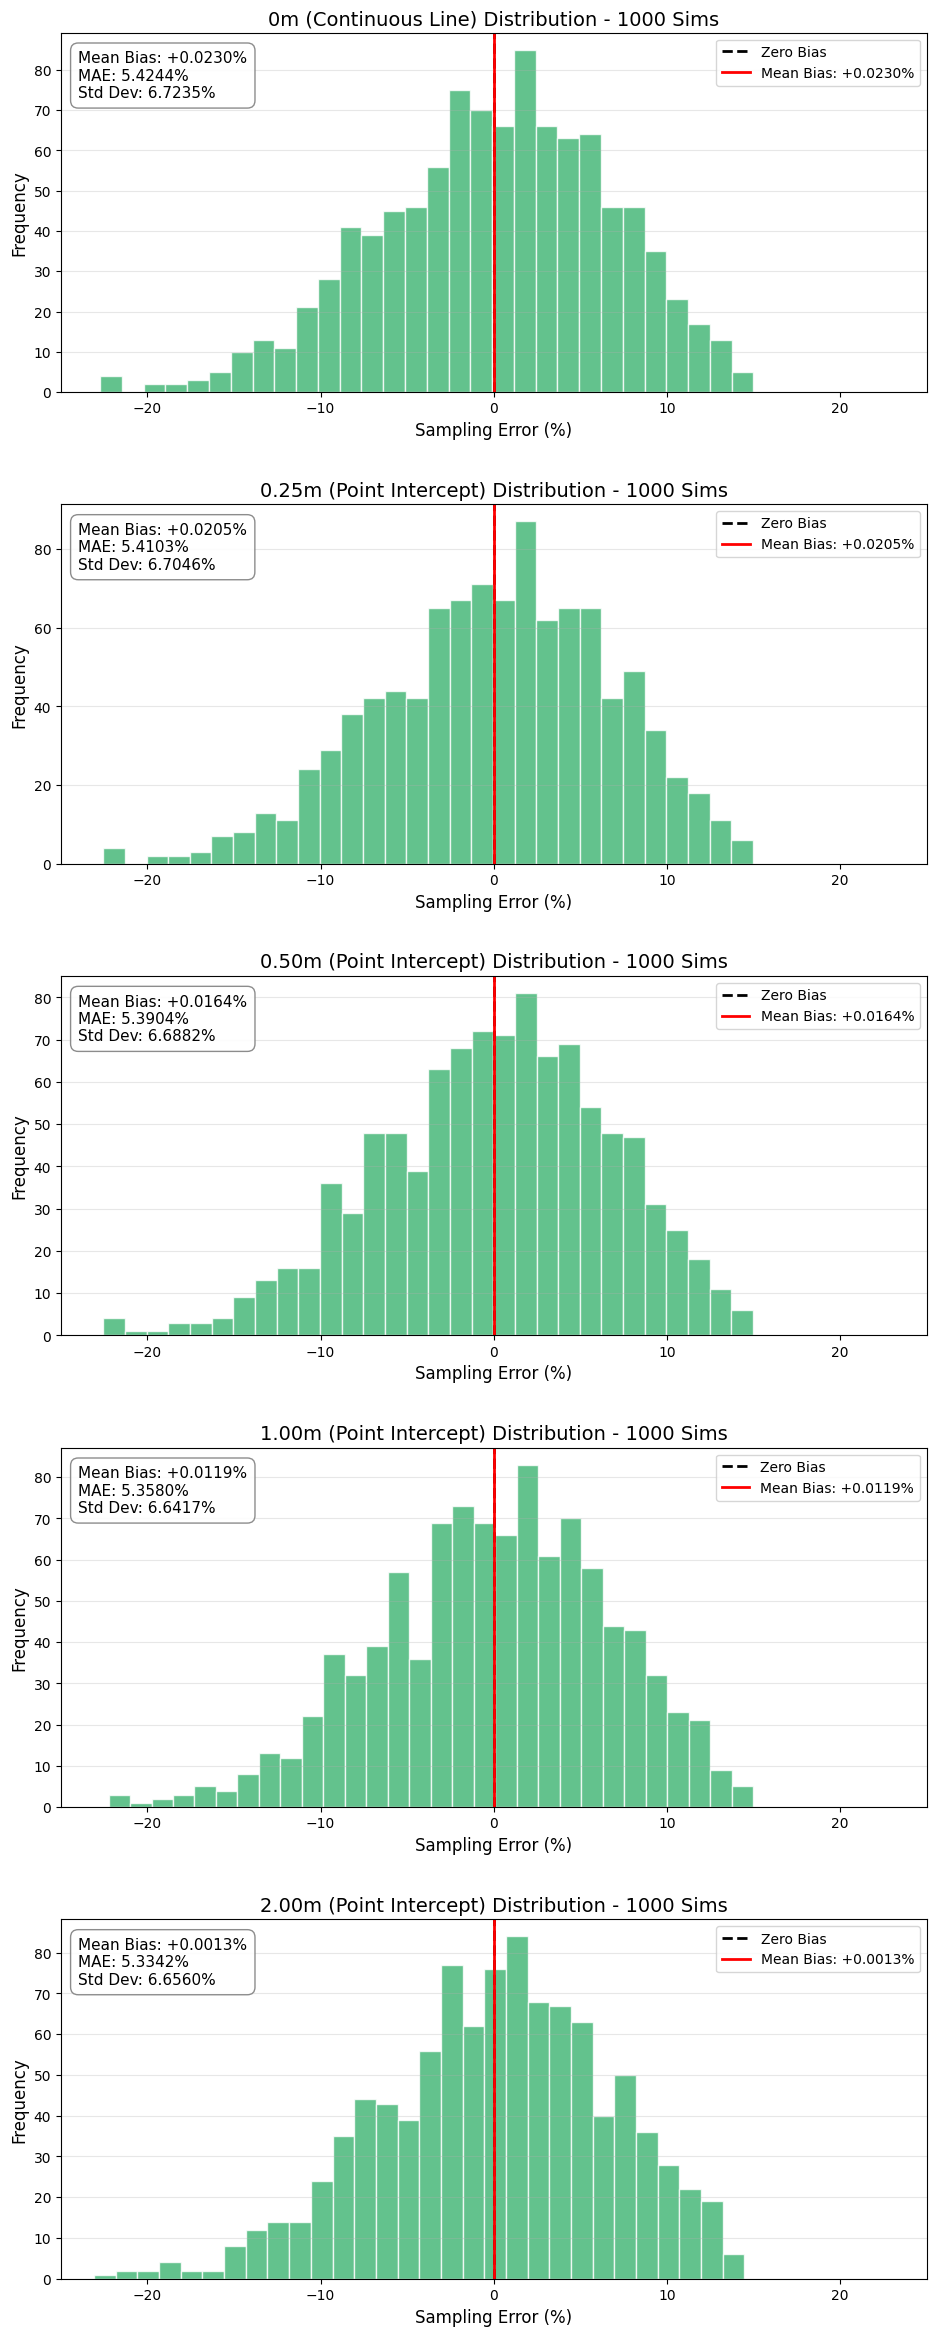

In [4]:
# ==========================================
# BLOCK 2: Headless Validation (All Scales)
# ==========================================
from shapely.geometry import MultiPoint

def run_thousand_simulations(num_iterations=1000, plot_radius=55, hub_radius=5):
    """Runs the NRI sampling logic headless across multiple sampling scales."""
    plot_circle = Point(0, 0).buffer(plot_radius)
    spokes = get_nri_spokes(hub_radius, plot_radius)
    total_transect_length = 3 * (plot_radius - hub_radius)
    spoke_length = plot_radius - hub_radius

    intervals = [0.0, 0.25, 0.50, 1.00, 2.00]
    interval_names = {0.0: '0m (Continuous Line)', 0.25: '0.25m (Point Intercept)',
                      0.50: '0.50m (Point Intercept)', 1.00: '1.00m (Point Intercept)',
                      2.00: '2.00m (Point Intercept)'}

    # Store errors for each protocol
    errors = {i: [] for i in intervals}

    print(f"Crunching {num_iterations} simulations across {len(intervals)} scales... please wait.")

    # OPTIMIZATION: Pre-calculate MultiPoint geometries for the point intercept intervals
    # Since the spokes don't move, the sampling coordinates are identical every iteration.
    sampling_points = {}
    for interval in intervals[1:]:
        pts = []
        for spoke in spokes:
            for d in np.arange(0, spoke_length + 0.001, interval):
                pts.append(spoke.interpolate(d))
        sampling_points[interval] = MultiPoint(pts)

    for i in range(num_iterations):
        # 1. Generate new shrubs (60 shrubs, 3m average radius)
        shrubs = generate_random_shrubs(60, plot_radius)
        shrub_union = unary_union(shrubs)

        # 2. Calculate True Bare Ground
        shrubs_in_plot = shrub_union.intersection(plot_circle)
        true_bare_area = plot_circle.area - shrubs_in_plot.area
        true_bg_pct = (true_bare_area / plot_circle.area) * 100

        # 3. Calculate Sampled Bare Ground for each protocol
        for interval in intervals:
            if interval == 0.0: # Continuous Line
                total_intercept = sum(spoke.intersection(shrub_union).length for spoke in spokes)
                sampled_bg_pct = (1 - (total_intercept / total_transect_length)) * 100
            else: # Point Intercept
                # Intersect pre-calculated points with the shrub union
                hits = sampling_points[interval].intersection(shrub_union)
                if hits.is_empty:
                    shrub_hits = 0
                elif hits.geom_type == 'Point':
                    shrub_hits = 1
                else:
                    shrub_hits = len(hits.geoms)

                total_pts = len(sampling_points[interval].geoms)
                bare_hits = total_pts - shrub_hits
                sampled_bg_pct = (bare_hits / total_pts) * 100 if total_pts > 0 else 0

            # 4. Record Error
            errors[interval].append(sampled_bg_pct - true_bg_pct)

    # --- Visualize Results ---
    from IPython.display import clear_output
    clear_output(wait=True)

    fig, axes = plt.subplots(5, 1, figsize=(10, 24))
    print("--- STATISTICAL SUMMARY (HIGH BARE GROUND) ---")

    for idx, interval in enumerate(intervals):
        ax = axes[idx]
        errs = errors[interval]
        mean_error = np.mean(errs)
        std_dev = np.std(errs)
        mae = np.mean(np.abs(errs))

        # Print stats directly to console
        print(f"Protocol: {interval_names[interval]}")
        print(f"  Mean Bias: {mean_error:+.4f}% | MAE: {mae:.4f}% | Std Dev: {std_dev:.4f}%\n")

        # Plot Histogram
        ax.hist(errs, bins=30, color='mediumseagreen', edgecolor='white', alpha=0.8)
        ax.axvline(0, color='black', linestyle='--', linewidth=2, label='Zero Bias')
        ax.axvline(mean_error, color='red', linewidth=2, label=f'Mean Bias: {mean_error:+.4f}%')

        ax.set_title(f"{interval_names[interval]} Distribution - {num_iterations} Sims", fontsize=14)
        ax.set_xlabel("Sampling Error (%)", fontsize=12)
        ax.set_ylabel("Frequency", fontsize=12)
        ax.legend(loc='upper right')
        ax.grid(axis='y', alpha=0.3)
        ax.set_xlim(-25, 25) # Standardized X-axis for visual comparison

        # Draw Stats Box
        stats_text = (f"Mean Bias: {mean_error:+.4f}%\n"
                      f"MAE: {mae:.4f}%\n"
                      f"Std Dev: {std_dev:.4f}%")
        ax.text(0.02, 0.95, stats_text, transform=ax.transAxes,
                fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9))

    plt.tight_layout(pad=3.0)
    plt.show()

# Execute the batch (Reduced to 10k initially for safe testing, adjust to 100k as needed)
run_thousand_simulations(1000)


### 0 cm interval figure

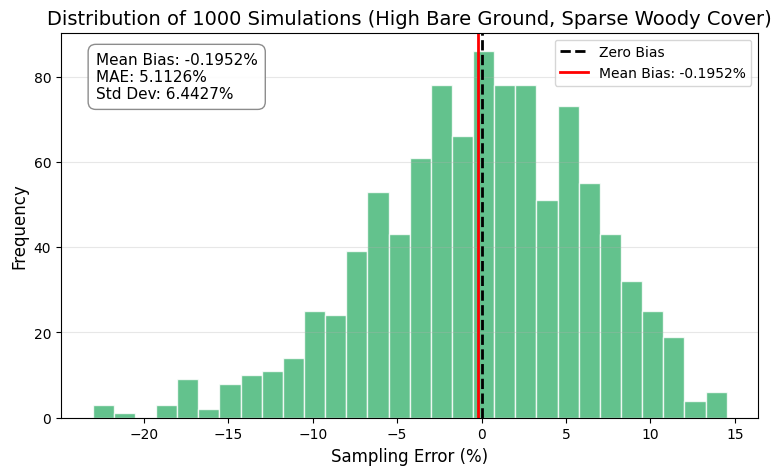

--- STATISTICAL SUMMARY ---
Mean Bias: -0.1952%
Mean Absolute Error: 5.1126%
Standard Deviation: 6.4427%


In [ ]:

def run_thousand_simulations(num_iterations=1000, plot_radius=55, hub_radius=5):
    """Runs the NRI sampling logic headless for 1000 iterations to verify accuracy."""
    plot_circle = Point(0, 0).buffer(plot_radius)
    spokes = get_nri_spokes(hub_radius, plot_radius)
    total_transect_length = 3 * (plot_radius - hub_radius)

    errors = []

    print(f"Crunching {num_iterations} simulations... please wait.")

    for i in range(num_iterations):
        # 1. Generate new shrubs (60 shrubs, 3m average radius)
        shrubs = generate_random_shrubs(60, plot_radius)
        shrub_union = unary_union(shrubs)

        # 2. Calculate True Bare Ground
        shrubs_in_plot = shrub_union.intersection(plot_circle)
        true_bare_area = plot_circle.area - shrubs_in_plot.area
        true_bg_pct = (true_bare_area / plot_circle.area) * 100

        # 3. Calculate Sampled Bare Ground (Continuous Line)
        total_intercept = 0
        for spoke in spokes:
            intersection = spoke.intersection(shrub_union)
            total_intercept += intersection.length

        sampled_bg_pct = (1 - (total_intercept / total_transect_length)) * 100

        # 4. Record Error
        errors.append(sampled_bg_pct - true_bg_pct)

    # --- Statistics ---
    mean_error = np.mean(errors)
    std_dev = np.std(errors)
    mae = np.mean(np.abs(errors)) # Mean Absolute Error

    # --- Visualize Results ---
    plt.figure(figsize=(9, 5))
    plt.hist(errors, bins=30, color='mediumseagreen', edgecolor='white', alpha=0.8)
    plt.axvline(0, color='black', linestyle='--', linewidth=2, label='Zero Bias')
    plt.axvline(mean_error, color='red', linewidth=2, label=f'Mean Bias: {mean_error:+.4f}%')

    plt.title(f"Distribution of {num_iterations} Simulations (High Bare Ground, Sparse Woody Cover)", fontsize=14)
    plt.xlabel("Sampling Error (%)", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(axis='y', alpha=0.3)

    # Draw Stats Box in the upper left corner
    stats_text = (
        f"Mean Bias: {mean_error:+.4f}%\n"
        f"MAE: {mae:.4f}%\n"
        f"Std Dev: {std_dev:.4f}%"
    )
    plt.gca().text(0.05, 0.95, stats_text, transform=plt.gca().transAxes,
                   fontsize=11, verticalalignment='top',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9))

    from IPython.display import clear_output
    clear_output(wait=True)
    plt.show()

    # Print summary to the output cell below the figure as well
    print("--- STATISTICAL SUMMARY ---")
    print(f"Mean Bias: {mean_error:+.4f}%")
    print(f"Mean Absolute Error: {mae:.4f}%")
    print(f"Standard Deviation: {std_dev:.4f}%")

# Execute the 1000-run batch
run_thousand_simulations(1000)


### (Not used) simple dynamic bare ground cover visualization

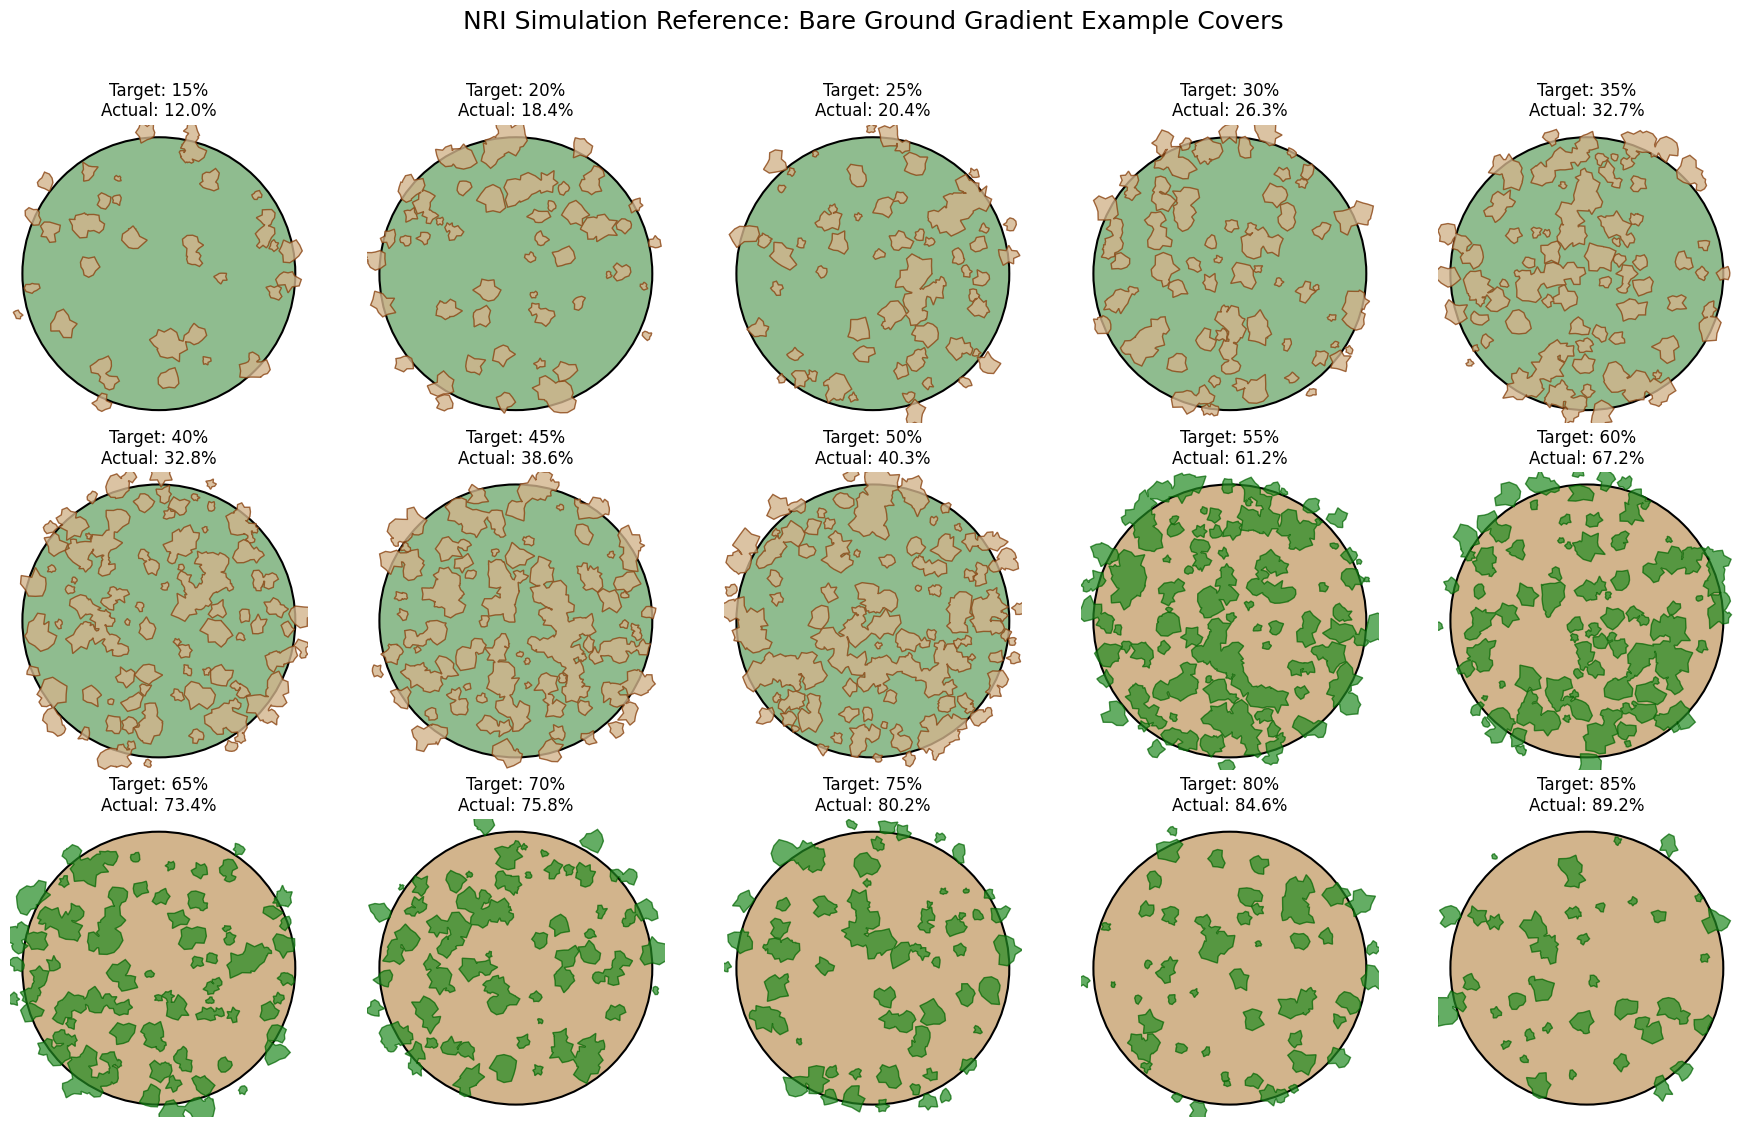

In [ ]:
# ==========================================
# Helper Block: Visualizing the Gradient
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point
from shapely.ops import unary_union

def visualize_ground_cover_gradient(plot_radius=55):
    """
    Generates a 3x5 grid of example ground covers from 15% to 85% bare ground.
    Demonstrates the ecological phase shift at the 50% threshold with a unified
    green/brown color scheme across all plots.
    """
    plot_circle = Point(0, 0).buffer(plot_radius)

    # Expected areas for the Boolean model
    E_r_squared = (1**2 + 1*5 + 5**2) / 3
    mean_patch_area = np.pi * E_r_squared
    plot_area = plot_circle.area
    area_ratio = plot_area / mean_patch_area

    # 15 intervals for a perfect 3x5 grid
    target_bgs = np.arange(15, 90, 5)

    fig, axes = plt.subplots(3, 5, figsize=(18, 11))
    fig.suptitle("NRI Simulation Reference: Bare Ground Gradient Example Covers", fontsize=18, y=1.02)
    axes = axes.flatten()

    for idx, target_bg in enumerate(target_bgs):
        ax = axes[idx]

        # Determine Ecological Phase Shift
        is_inverted = target_bg <= 50
        target_coverage = target_bg / 100.0 if is_inverted else 1 - (target_bg / 100.0)

        # Calculate required N using the Poisson Boolean Model
        num_shapes = int(-area_ratio * np.log(1 - target_coverage))

        # Generate shapes
        shapes = generate_random_shrubs(num_shapes, plot_radius)
        shape_union = unary_union(shapes)

        # Calculate True Bare Ground to display actual achieved % vs target
        shapes_in_plot = shape_union.intersection(plot_circle)
        if is_inverted:
            actual_bg_pct = (shapes_in_plot.area / plot_area) * 100
        else:
            actual_bg_pct = ((plot_area - shapes_in_plot.area) / plot_area) * 100

        # Plotting setup
        ax.set_aspect('equal')
        ax.axis('off')

        # Draw plot boundary (background)
        if is_inverted:
            # Herbaceous background (Green)
            bg_patch = plt.Circle((0, 0), plot_radius, color='darkseagreen', ec='black', lw=1.5)
            ax.add_patch(bg_patch)

            # Draw Bare Ground Patches (Tan/Brown)
            if not shape_union.is_empty:
                geoms = [shape_union] if shape_union.geom_type == 'Polygon' else shape_union.geoms
                for geom in geoms:
                    x, y = geom.exterior.xy
                    ax.fill(x, y, alpha=0.8, fc='tan', ec='saddlebrown', lw=1)
        else:
            # Bare dirt background (Tan to match the patches above)
            bg_patch = plt.Circle((0, 0), plot_radius, color='tan', ec='black', lw=1.5)
            ax.add_patch(bg_patch)

            # Draw Shrubs (Green)
            if not shape_union.is_empty:
                geoms = [shape_union] if shape_union.geom_type == 'Polygon' else shape_union.geoms
                for geom in geoms:
                    x, y = geom.exterior.xy
                    # Increased alpha slightly from 0.5 to 0.7 for better contrast against tan
                    ax.fill(x, y, alpha=0.7, fc='forestgreen', ec='darkgreen', lw=1)

        # Display Target vs Actual in the title
        ax.set_title(f"Target: {target_bg}%\nActual: {actual_bg_pct:.1f}%", fontsize=12)

        # Lock axes to slightly outside the plot radius
        ax.set_xlim(-60, 60)
        ax.set_ylim(-60, 60)

    plt.tight_layout()
    plt.show()

# Run the visualizer
visualize_ground_cover_gradient()


### (Not used) simple dynamic bare ground cover % distributions

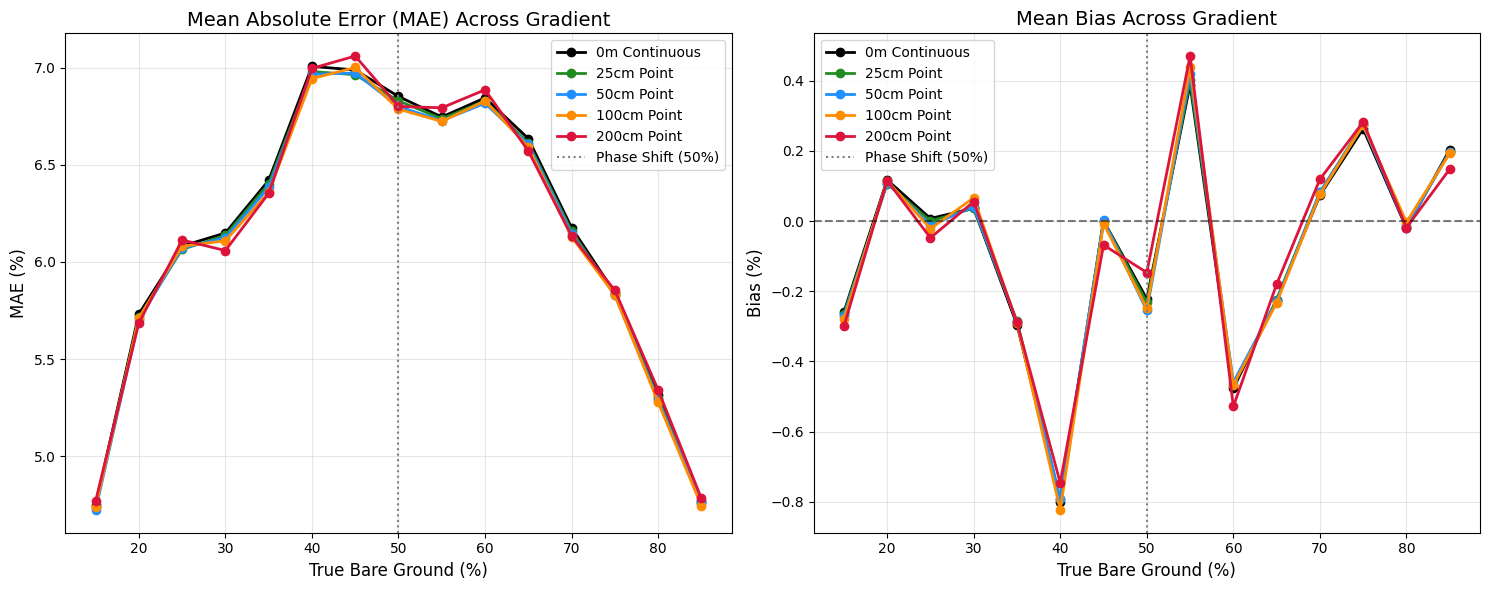

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import Point, MultiPoint
from shapely.ops import unary_union

# Re-use your existing `create_irregular_shrub`, `get_nri_spokes`, etc.
# Note: Modified generate_random_shrubs to accept a dynamic `num_shrubs`
def generate_random_shrubs(num_shrubs, plot_radius=55):
    shrubs = []
    max_shrub_radius = 5.0
    generation_radius = plot_radius + max_shrub_radius
    for _ in range(num_shrubs):
        radius = np.random.uniform(1.0, 5.0)
        r = generation_radius * np.sqrt(np.random.uniform(0, 1))
        theta = np.random.uniform(0, 2 * np.pi)
        x = r * np.cos(theta)
        y = r * np.sin(theta)
        shrubs.append(create_irregular_shrub(x, y, radius))
    return shrubs

def run_gradient_simulation(runs_per_interval=1000, plot_radius=55, hub_radius=5):
    plot_circle = Point(0, 0).buffer(plot_radius)
    spokes = get_nri_spokes(hub_radius, plot_radius)
    total_transect_length = 3 * (plot_radius - hub_radius)
    spoke_length = plot_radius - hub_radius

    # Expected areas for the Boolean model
    E_r_squared = (1**2 + 1*5 + 5**2) / 3  # Expected R^2 for Uniform(1, 5)
    mean_patch_area = np.pi * E_r_squared
    plot_area = plot_circle.area
    area_ratio = plot_area / mean_patch_area

    intervals = [0.0, 0.25, 0.50, 1.00, 2.00]
    interval_names = {0.0: '0m Continuous', 0.25: '25cm Point',
                      0.50: '50cm Point', 1.00: '100cm Point', 2.00: '200cm Point'}

    # Pre-calculate sampling points for speed
    sampling_points = {}
    for interval in intervals[1:]:
        pts = [spoke.interpolate(d) for spoke in spokes for d in np.arange(0, spoke_length + 0.001, interval)]
        sampling_points[interval] = MultiPoint(pts)

    target_bgs = np.arange(15, 90, 5) # 15% to 85%
    results = []

    print(f"Starting Gradient Simulation ({len(target_bgs)} targets x {runs_per_interval} runs = {len(target_bgs) * runs_per_interval} total iterations)")

    for target_bg in target_bgs:
        print(f"Crunching target: ~{target_bg}% Bare Ground...")

        # Determine Ecological Phase
        is_inverted = target_bg <= 50

        # Calculate target shape coverage
        if is_inverted:
            target_coverage = target_bg / 100.0       # We are generating bare dirt
        else:
            target_coverage = 1 - (target_bg / 100.0) # We are generating shrubs

        # Calculate required N using the Poisson Boolean Model
        num_shapes = int(-area_ratio * np.log(1 - target_coverage))

        # Temporary storage for this interval's 1000 runs
        interval_errors = {i: [] for i in intervals}

        for _ in range(runs_per_interval):
            shapes = generate_random_shrubs(num_shapes, plot_radius)
            shape_union = unary_union(shapes)
            shapes_in_plot = shape_union.intersection(plot_circle)

            # Calculate True Bare Ground based on current phase
            if is_inverted:
                true_bg_pct = (shapes_in_plot.area / plot_area) * 100
            else:
                true_bg_pct = ((plot_area - shapes_in_plot.area) / plot_area) * 100

            # Calculate Sampled Bare Ground
            for interval in intervals:
                if interval == 0.0:
                    intercept = sum(spoke.intersection(shape_union).length for spoke in spokes)
                    sampled_pct = (intercept / total_transect_length) * 100 if is_inverted else (1 - (intercept / total_transect_length)) * 100
                else:
                    hits = sampling_points[interval].intersection(shape_union)
                    shape_hits = 0 if hits.is_empty else (1 if hits.geom_type == 'Point' else len(hits.geoms))
                    total_pts = len(sampling_points[interval].geoms)

                    if is_inverted:
                        sampled_pct = (shape_hits / total_pts) * 100
                    else:
                        bare_hits = total_pts - shape_hits
                        sampled_pct = (bare_hits / total_pts) * 100

                interval_errors[interval].append(sampled_pct - true_bg_pct)

        # Record aggregated stats for this target interval
        for interval in intervals:
            results.append({
                'Target_BG': target_bg,
                'Protocol': interval_names[interval],
                'Mean_Bias': np.mean(interval_errors[interval]),
                'MAE': np.mean(np.abs(interval_errors[interval])),
                'Std_Dev': np.std(interval_errors[interval])
            })

    # Convert to DataFrame for easy plotting
    df = pd.DataFrame(results)

    # --- Visualize the Gradient ---
    from IPython.display import clear_output
    clear_output(wait=True)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    colors = ['black', 'forestgreen', 'dodgerblue', 'darkorange', 'crimson']

    for idx, interval in enumerate(intervals):
        protocol = interval_names[interval]
        subset = df[df['Protocol'] == protocol]

        # Plot MAE
        ax1.plot(subset['Target_BG'], subset['MAE'], marker='o', lw=2, color=colors[idx], label=protocol)
        # Plot Mean Bias
        ax2.plot(subset['Target_BG'], subset['Mean_Bias'], marker='o', lw=2, color=colors[idx], label=protocol)

    # Styling MAE Plot
    ax1.set_title("Mean Absolute Error (MAE) Across Gradient", fontsize=14)
    ax1.set_xlabel("True Bare Ground (%)", fontsize=12)
    ax1.set_ylabel("MAE (%)", fontsize=12)
    ax1.axvline(50, color='gray', linestyle=':', label='Phase Shift (50%)')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Styling Bias Plot
    ax2.set_title("Mean Bias Across Gradient", fontsize=14)
    ax2.set_xlabel("True Bare Ground (%)", fontsize=12)
    ax2.set_ylabel("Bias (%)", fontsize=12)
    ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax2.axvline(50, color='gray', linestyle=':', label='Phase Shift (50%)')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

    return df

# Run the gradient! (Takes a moment for 15,000 simulations)
results_df = run_gradient_simulation(1000)


### (Not used) blended dynamic bare ground cover visualization

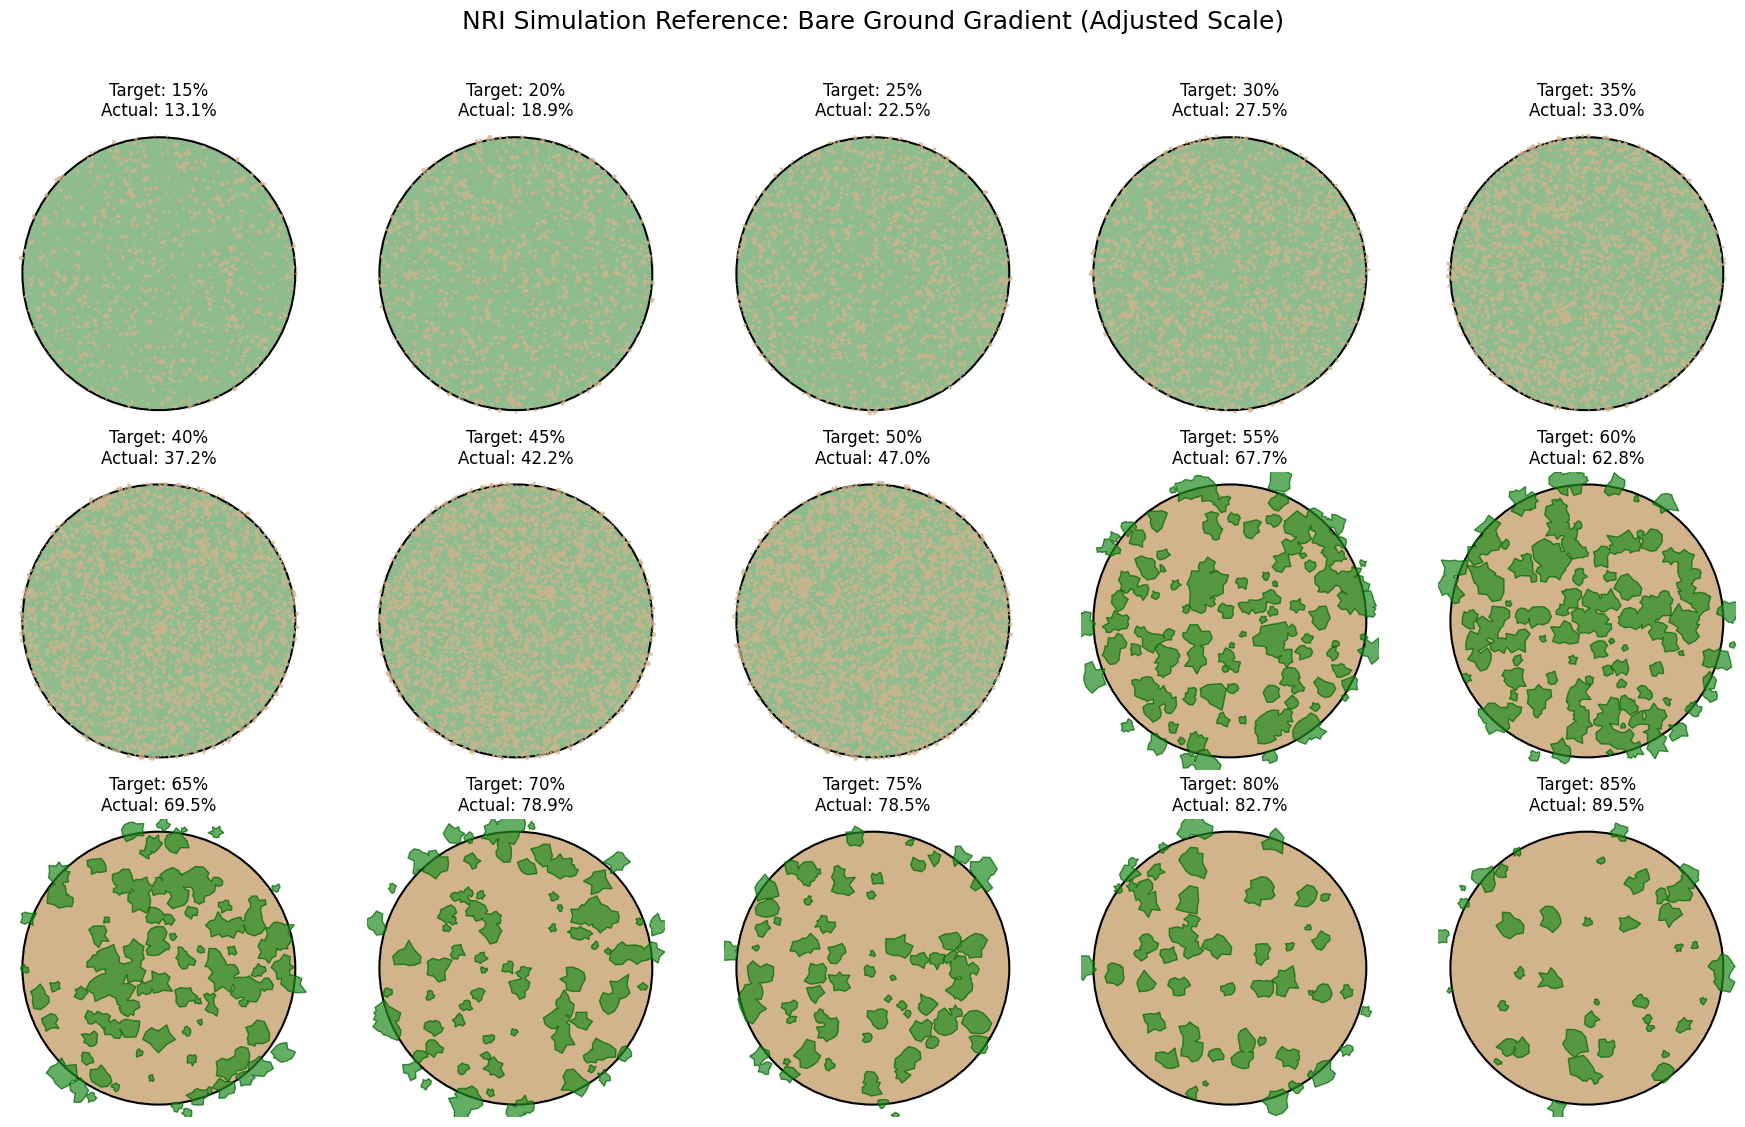

In [ ]:
# ==========================================
# Helper Block: Visualizing the Gradient (Bunch Grass Fix)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
from shapely.ops import unary_union

# --- Refactored Geometry Generators ---
def create_irregular_shape(center_x, center_y, base_radius, num_points=12):
    angles = np.linspace(0, 2 * np.pi, num_points, endpoint=False)
    points = []
    for angle in angles:
        r = base_radius * np.random.uniform(0.6, 1.4)
        points.append((center_x + r * np.cos(angle), center_y + r * np.sin(angle)))
    return Polygon(points)

def generate_random_shapes(num_shapes, plot_radius, r_min, r_max):
    """Now accepts dynamic minimum and maximum radii."""
    shapes = []
    generation_radius = plot_radius + r_max
    for _ in range(num_shapes):
        radius = np.random.uniform(r_min, r_max)
        r = generation_radius * np.sqrt(np.random.uniform(0, 1))
        theta = np.random.uniform(0, 2 * np.pi)
        x = r * np.cos(theta)
        y = r * np.sin(theta)
        shapes.append(create_irregular_shape(x, y, radius))
    return shapes

# --- Visualization Logic ---
def visualize_ground_cover_gradient(plot_radius=55):
    plot_circle = Point(0, 0).buffer(plot_radius)
    plot_area = plot_circle.area

    target_bgs = np.arange(15, 90, 5)

    fig, axes = plt.subplots(3, 5, figsize=(18, 11))
    fig.suptitle("NRI Simulation Reference: Bare Ground Gradient (Adjusted Scale)", fontsize=18, y=1.02)
    axes = axes.flatten()

    for idx, target_bg in enumerate(target_bgs):
        ax = axes[idx]

        is_inverted = target_bg <= 50

        # ECOLOGICAL SCALING RULES
        if is_inverted:
            target_coverage = target_bg / 100.0
            r_min, r_max = 0.2, 1.0  # Tiny interstitial dirt patches (Bunch Grass matrix)
        else:
            target_coverage = 1 - (target_bg / 100.0)
            r_min, r_max = 1.0, 5.0  # Standard shrub canopies

        # Dynamically calculate Area Ratio based on current r_min and r_max
        E_r_squared = (r_min**2 + r_min*r_max + r_max**2) / 3
        mean_patch_area = np.pi * E_r_squared
        area_ratio = plot_area / mean_patch_area

        # Calculate N
        num_shapes = int(-area_ratio * np.log(1 - target_coverage))

        # Generate and union
        shapes = generate_random_shapes(num_shapes, plot_radius, r_min, r_max)
        shape_union = unary_union(shapes)

        # Actual % Calculation
        shapes_in_plot = shape_union.intersection(plot_circle)
        if is_inverted:
            actual_bg_pct = (shapes_in_plot.area / plot_area) * 100
        else:
            actual_bg_pct = ((plot_area - shapes_in_plot.area) / plot_area) * 100

        # Plotting Setup
        ax.set_aspect('equal')
        ax.axis('off')

        if is_inverted:
            bg_patch = plt.Circle((0, 0), plot_radius, color='darkseagreen', ec='black', lw=1.5)
            ax.add_patch(bg_patch)
            if not shape_union.is_empty:
                geoms = [shape_union] if shape_union.geom_type == 'Polygon' else shape_union.geoms
                for geom in geoms:
                    x, y = geom.exterior.xy
                    ax.fill(x, y, alpha=0.8, fc='tan', ec='none') # Removed edge color to prevent clutter on tiny shapes
        else:
            bg_patch = plt.Circle((0, 0), plot_radius, color='tan', ec='black', lw=1.5)
            ax.add_patch(bg_patch)
            if not shape_union.is_empty:
                geoms = [shape_union] if shape_union.geom_type == 'Polygon' else shape_union.geoms
                for geom in geoms:
                    x, y = geom.exterior.xy
                    ax.fill(x, y, alpha=0.7, fc='forestgreen', ec='darkgreen', lw=1)

        ax.set_title(f"Target: {target_bg}%\nActual: {actual_bg_pct:.1f}%", fontsize=12)
        ax.set_xlim(-60, 60)
        ax.set_ylim(-60, 60)

    plt.tight_layout()
    plt.show()

# Run the visualizer
visualize_ground_cover_gradient()


### Dynamic bare ground cover visualization

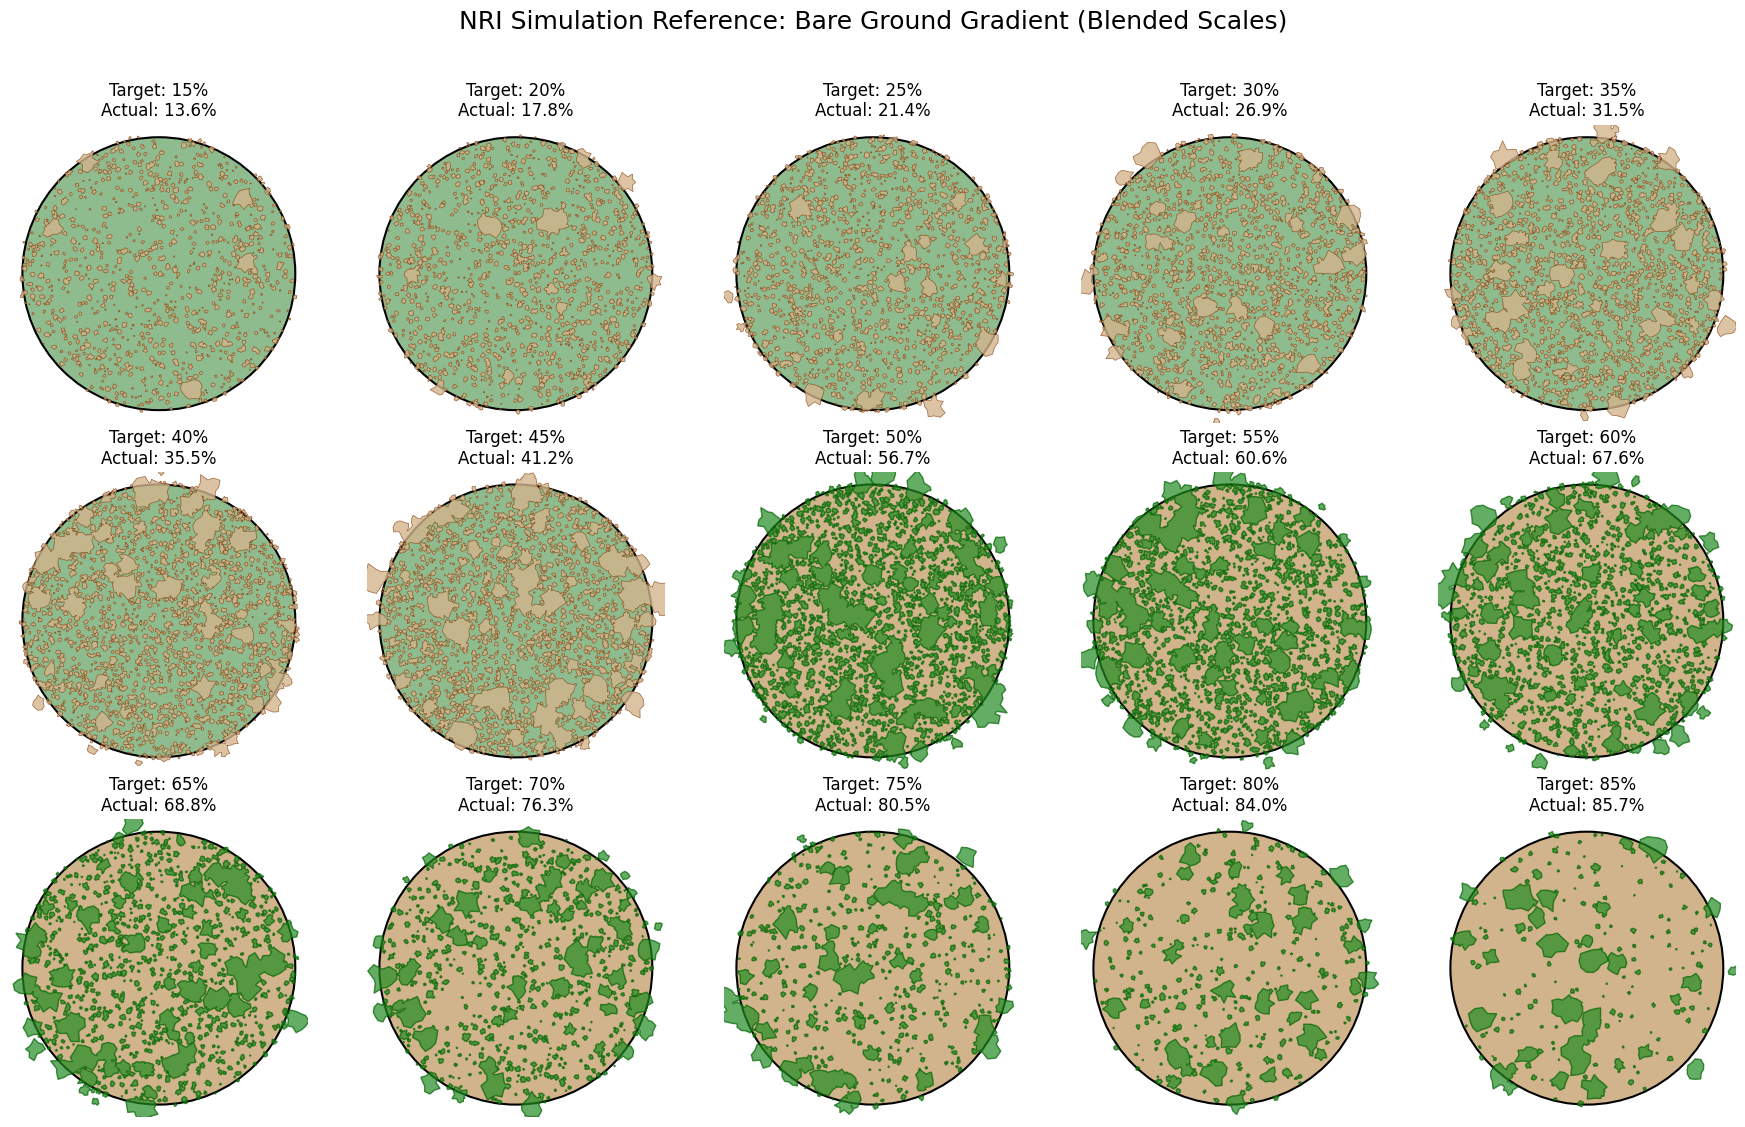

In [ ]:
# ==========================================
# Helper Block: Visualizing the Gradient (Blended Scale)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
from shapely.ops import unary_union

# --- Refactored Geometry Generators ---
def create_irregular_shape(center_x, center_y, base_radius, num_points=12):
    angles = np.linspace(0, 2 * np.pi, num_points, endpoint=False)
    points = []
    for angle in angles:
        r = base_radius * np.random.uniform(0.6, 1.4)
        points.append((center_x + r * np.cos(angle), center_y + r * np.sin(angle)))
    return Polygon(points)

def generate_random_shapes(num_shapes, plot_radius, r_min, r_max):
    shapes = []
    generation_radius = plot_radius + r_max
    for _ in range(num_shapes):
        radius = np.random.uniform(r_min, r_max)
        r = generation_radius * np.sqrt(np.random.uniform(0, 1))
        theta = np.random.uniform(0, 2 * np.pi)
        x = r * np.cos(theta)
        y = r * np.sin(theta)
        shapes.append(create_irregular_shape(x, y, radius))
    return shapes

# --- Visualization Logic ---
def visualize_ground_cover_gradient(plot_radius=55):
    plot_circle = Point(0, 0).buffer(plot_radius)
    plot_area = plot_circle.area

    # Calculate Expected Patch Areas for both scales
    E_r2_macro = (1.0**2 + 1.0*5.0 + 5.0**2) / 3
    E_r2_micro = (0.2**2 + 0.2*1.0 + 1.0**2) / 3

    mean_area_macro = np.pi * E_r2_macro
    mean_area_micro = np.pi * E_r2_micro

    target_bgs = np.arange(15, 90, 5)

    fig, axes = plt.subplots(3, 5, figsize=(18, 11))
    fig.suptitle("NRI Simulation Reference: Bare Ground Gradient (Blended Scales)", fontsize=18, y=1.02)
    axes = axes.flatten()

    for idx, target_bg in enumerate(target_bgs):
        ax = axes[idx]

        # MODIFIED: Phase Shift now strictly less than 50
        is_inverted = target_bg < 50

        # Calculate base target coverage
        target_coverage = target_bg / 100.0 if is_inverted else 1 - (target_bg / 100.0)

        # Total 'virtual' area we need to generate to hit the logarithmic target
        A_target_total = -plot_area * np.log(1 - target_coverage)

        # BLENDING WEIGHT: Macro dominance scales directly with Bare Ground %
        w_macro = target_bg / 100.0

        # Split the target area into macro and micro pools
        A_target_macro = A_target_total * w_macro
        A_target_micro = A_target_total * (1 - w_macro)

        # Calculate N for each pool
        N_macro = int(A_target_macro / mean_area_macro)
        N_micro = int(A_target_micro / mean_area_micro)

        # Generate and combine shapes
        shapes_macro = generate_random_shapes(N_macro, plot_radius, 1.0, 5.0)
        shapes_micro = generate_random_shapes(N_micro, plot_radius, 0.2, 1.0)
        shape_union = unary_union(shapes_macro + shapes_micro)

        # Calculate Actual %
        shapes_in_plot = shape_union.intersection(plot_circle)
        if is_inverted:
            actual_bg_pct = (shapes_in_plot.area / plot_area) * 100
        else:
            actual_bg_pct = ((plot_area - shapes_in_plot.area) / plot_area) * 100

        # Plotting Setup
        ax.set_aspect('equal')
        ax.axis('off')

        if is_inverted:
            bg_patch = plt.Circle((0, 0), plot_radius, color='darkseagreen', ec='black', lw=1.5)
            ax.add_patch(bg_patch)
            if not shape_union.is_empty:
                geoms = [shape_union] if shape_union.geom_type == 'Polygon' else shape_union.geoms
                for geom in geoms:
                    x, y = geom.exterior.xy
                    ax.fill(x, y, alpha=0.8, fc='tan', ec='saddlebrown', lw=0.5)
        else:
            bg_patch = plt.Circle((0, 0), plot_radius, color='tan', ec='black', lw=1.5)
            ax.add_patch(bg_patch)
            if not shape_union.is_empty:
                geoms = [shape_union] if shape_union.geom_type == 'Polygon' else shape_union.geoms
                for geom in geoms:
                    x, y = geom.exterior.xy
                    ax.fill(x, y, alpha=0.7, fc='forestgreen', ec='darkgreen', lw=1)

        ax.set_title(f"Target: {target_bg}%\nActual: {actual_bg_pct:.1f}%", fontsize=12)
        ax.set_xlim(-60, 60)
        ax.set_ylim(-60, 60)

    plt.tight_layout()
    plt.show()

# Run the visualizer
visualize_ground_cover_gradient()


### Dynamic bare ground cover % distributions

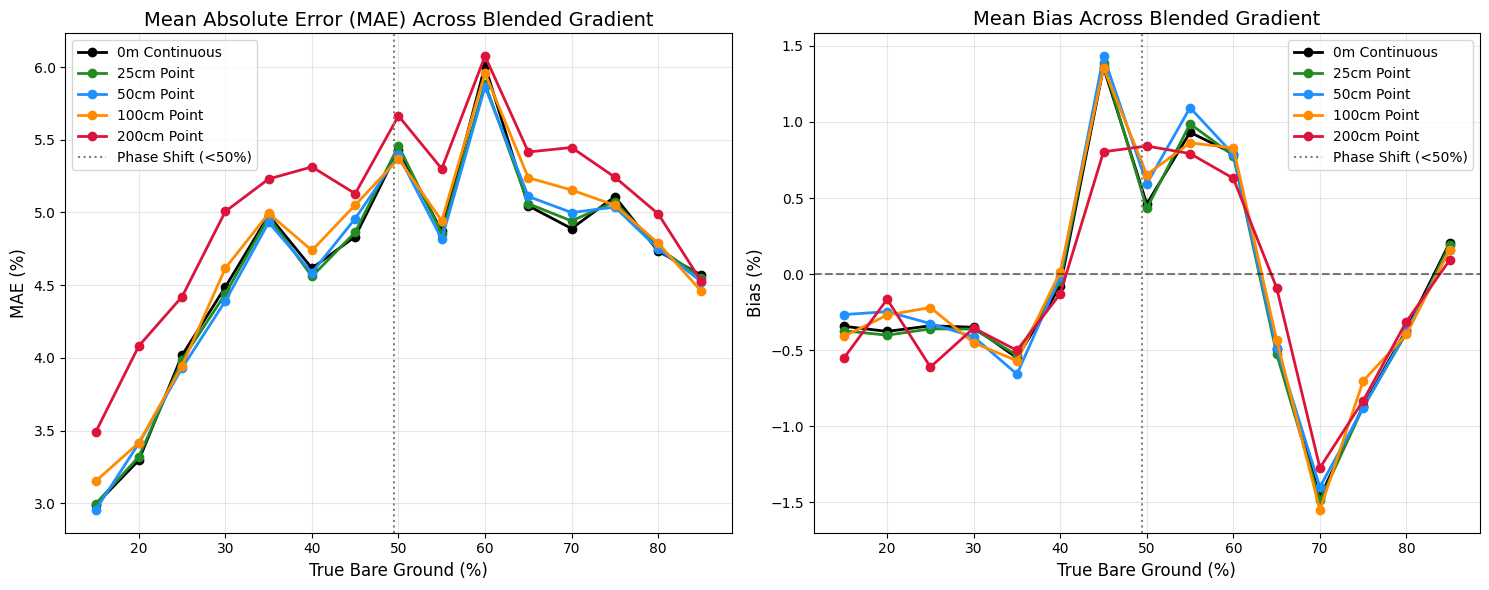

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import Point, MultiPoint, Polygon
from shapely.ops import unary_union

# ==========================================
# Base Geometry Functions
# ==========================================
def create_irregular_shape(center_x, center_y, base_radius, num_points=12):
    angles = np.linspace(0, 2 * np.pi, num_points, endpoint=False)
    points = []
    for angle in angles:
        r = base_radius * np.random.uniform(0.6, 1.4)
        points.append((center_x + r * np.cos(angle), center_y + r * np.sin(angle)))
    return Polygon(points)

def generate_random_shapes(num_shapes, plot_radius, r_min, r_max):
    shapes = []
    generation_radius = plot_radius + r_max
    for _ in range(num_shapes):
        radius = np.random.uniform(r_min, r_max)
        r = generation_radius * np.sqrt(np.random.uniform(0, 1))
        theta = np.random.uniform(0, 2 * np.pi)
        x = r * np.cos(theta)
        y = r * np.sin(theta)
        shapes.append(create_irregular_shape(x, y, radius))
    return shapes

# ==========================================
# Headless Gradient Simulation
# ==========================================
def run_gradient_simulation(runs_per_interval=1000, plot_radius=55, hub_radius=5):
    plot_circle = Point(0, 0).buffer(plot_radius)
    spokes = get_nri_spokes(hub_radius, plot_radius)
    total_transect_length = 3 * (plot_radius - hub_radius)
    spoke_length = plot_radius - hub_radius
    plot_area = plot_circle.area

    # Calculate Expected Patch Areas for both scales
    E_r2_macro = (1.0**2 + 1.0*5.0 + 5.0**2) / 3
    E_r2_micro = (0.2**2 + 0.2*1.0 + 1.0**2) / 3
    mean_area_macro = np.pi * E_r2_macro
    mean_area_micro = np.pi * E_r2_micro

    intervals = [0.0, 0.25, 0.50, 1.00, 2.00]
    interval_names = {0.0: '0m Continuous', 0.25: '25cm Point',
                      0.50: '50cm Point', 1.00: '100cm Point', 2.00: '200cm Point'}

    # Pre-calculate sampling points for speed
    sampling_points = {}
    for interval in intervals[1:]:
        pts = [spoke.interpolate(d) for spoke in spokes for d in np.arange(0, spoke_length + 0.001, interval)]
        sampling_points[interval] = MultiPoint(pts)

    target_bgs = np.arange(15, 90, 5) # 15% to 85%
    results = []

    print(f"Starting Gradient Simulation ({len(target_bgs)} targets x {runs_per_interval} runs = {len(target_bgs) * runs_per_interval} total iterations)")

    for target_bg in target_bgs:
        print(f"Crunching target: ~{target_bg}% Bare Ground...")

        # MODIFIED: Phase Shift now strictly less than 50
        is_inverted = target_bg < 50

        # Calculate target shape coverage
        target_coverage = target_bg / 100.0 if is_inverted else 1 - (target_bg / 100.0)

        # Total 'virtual' area we need to generate to hit the logarithmic target
        A_target_total = -plot_area * np.log(1 - target_coverage)

        # BLENDING WEIGHT: Macro dominance scales directly with Bare Ground %
        w_macro = target_bg / 100.0

        # Split the target area into macro and micro pools
        A_target_macro = A_target_total * w_macro
        A_target_micro = A_target_total * (1 - w_macro)

        # Calculate N for each pool
        N_macro = int(A_target_macro / mean_area_macro)
        N_micro = int(A_target_micro / mean_area_micro)

        interval_errors = {i: [] for i in intervals}

        for _ in range(runs_per_interval):
            # Generate and blend both scale pools
            shapes_macro = generate_random_shapes(N_macro, plot_radius, 1.0, 5.0)
            shapes_micro = generate_random_shapes(N_micro, plot_radius, 0.2, 1.0)
            shape_union = unary_union(shapes_macro + shapes_micro)

            shapes_in_plot = shape_union.intersection(plot_circle)

            # Calculate True Bare Ground
            if is_inverted:
                true_bg_pct = (shapes_in_plot.area / plot_area) * 100
            else:
                true_bg_pct = ((plot_area - shapes_in_plot.area) / plot_area) * 100

            # Calculate Sampled Bare Ground
            for interval in intervals:
                if interval == 0.0:
                    intercept = sum(spoke.intersection(shape_union).length for spoke in spokes)
                    sampled_pct = (intercept / total_transect_length) * 100 if is_inverted else (1 - (intercept / total_transect_length)) * 100
                else:
                    hits = sampling_points[interval].intersection(shape_union)
                    shape_hits = 0 if hits.is_empty else (1 if hits.geom_type == 'Point' else len(hits.geoms))
                    total_pts = len(sampling_points[interval].geoms)

                    if is_inverted:
                        sampled_pct = (shape_hits / total_pts) * 100
                    else:
                        bare_hits = total_pts - shape_hits
                        sampled_pct = (bare_hits / total_pts) * 100

                interval_errors[interval].append(sampled_pct - true_bg_pct)

        # Record aggregated stats
        for interval in intervals:
            results.append({
                'Target_BG': target_bg,
                'Protocol': interval_names[interval],
                'Mean_Bias': np.mean(interval_errors[interval]),
                'MAE': np.mean(np.abs(interval_errors[interval])),
                'Std_Dev': np.std(interval_errors[interval])
            })

    df = pd.DataFrame(results)

    # --- Visualize the Gradient ---
    from IPython.display import clear_output
    clear_output(wait=True)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    colors = ['black', 'forestgreen', 'dodgerblue', 'darkorange', 'crimson']

    for idx, interval in enumerate(intervals):
        protocol = interval_names[interval]
        subset = df[df['Protocol'] == protocol]

        ax1.plot(subset['Target_BG'], subset['MAE'], marker='o', lw=2, color=colors[idx], label=protocol)
        ax2.plot(subset['Target_BG'], subset['Mean_Bias'], marker='o', lw=2, color=colors[idx], label=protocol)

    # Styling MAE Plot
    ax1.set_title("Mean Absolute Error (MAE) Across Blended Gradient", fontsize=14)
    ax1.set_xlabel("True Bare Ground (%)", fontsize=12)
    ax1.set_ylabel("MAE (%)", fontsize=12)
    ax1.axvline(49.5, color='gray', linestyle=':', label='Phase Shift (<50%)')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Styling Bias Plot
    ax2.set_title("Mean Bias Across Blended Gradient", fontsize=14)
    ax2.set_xlabel("True Bare Ground (%)", fontsize=12)
    ax2.set_ylabel("Bias (%)", fontsize=12)
    ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax2.axvline(49.5, color='gray', linestyle=':', label='Phase Shift (<50%)')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

    return df

# Execute the run!
results_df = run_gradient_simulation(100)


### All variables dynamic bare ground cover % distributions

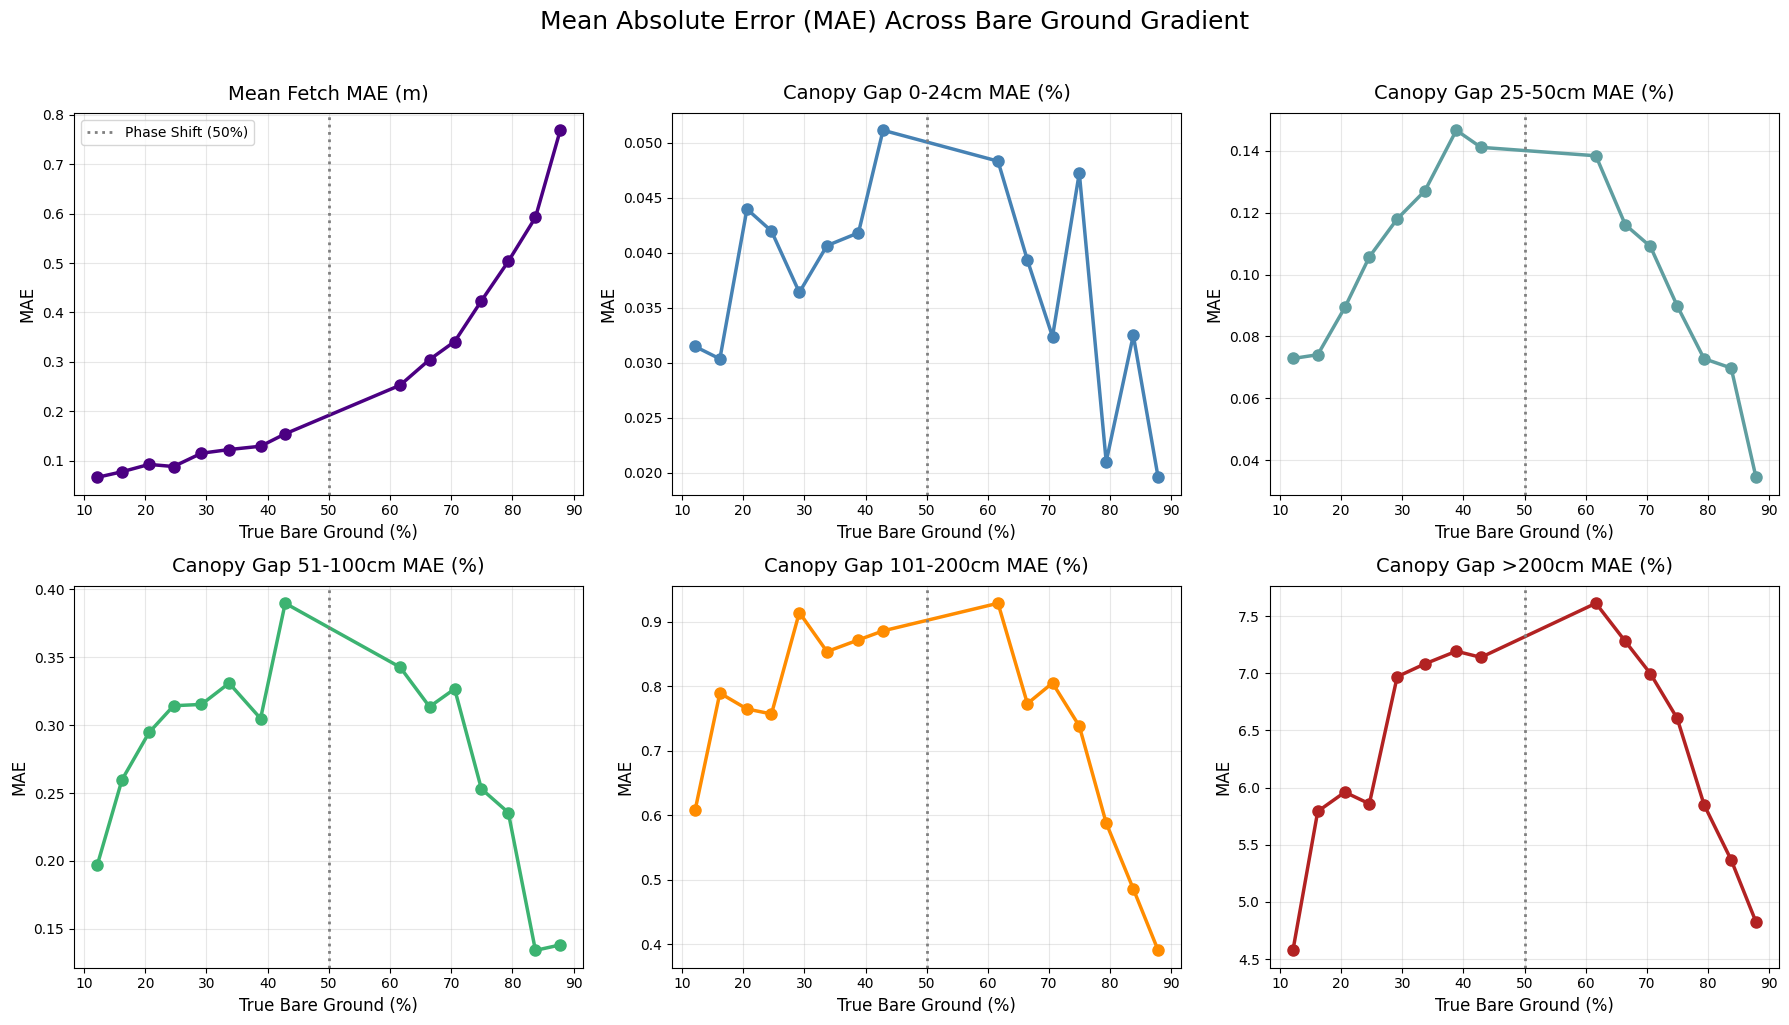

In [5]:
# ====================================================================
# BLOCK 3: Dynamic Gradient Validations (Fetch & Canopy Gap Fractions)
# ====================================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import Point
from shapely.ops import unary_union
from scipy.ndimage import distance_transform_edt
from matplotlib.path import Path
from IPython.display import clear_output

def polygon_to_path(polygon):
    """Converts a Shapely Polygon (including holes) to a matplotlib Path for fast rasterization."""
    vertices = list(polygon.exterior.coords)
    codes = [Path.MOVETO] + [Path.LINETO] * (len(vertices) - 2) + [Path.CLOSEPOLY]
    for interior in polygon.interiors:
        interior_vertices = list(interior.coords)
        vertices.extend(interior_vertices)
        codes.extend([Path.MOVETO] + [Path.LINETO] * (len(interior_vertices) - 2) + [Path.CLOSEPOLY])
    return Path(vertices, codes)

def get_gap_lengths(transect_array, gap_val, p_size):
    """Extracts lengths of continuous sequences matching gap_val."""
    padded = np.concatenate(([False], (transect_array == gap_val), [False]))
    diffs = np.diff(padded.astype(int))
    starts, ends = np.where(diffs == 1)[0], np.where(diffs == -1)[0]
    return (ends - starts) * p_size

def run_fetch_gap_gradient_simulation(num_iterations=150, plot_radius=55, hub_radius=5, cell_size=0.05):
    """
    Simulates the gradient of bare ground to calculate Mean Absolute Error (MAE)
    for Mean Fetch and Canopy Gap Fractions across multiple intervals.
    """
    print(f"Initializing 2D Raster Grid ({cell_size}m resolution)...")

    # 1. Grid Setup (Rasterization Canvas)
    grid_size = int((plot_radius * 2) / cell_size)
    x = np.linspace(-plot_radius, plot_radius, grid_size)
    y = np.linspace(-plot_radius, plot_radius, grid_size) # Matplotlib paths use standard cartesian
    X, Y = np.meshgrid(x, y)

    # Valid mask for the circular plot boundary
    dist_from_center = np.sqrt(X**2 + Y**2)
    valid_mask = dist_from_center <= plot_radius
    total_valid_pixels = np.sum(valid_mask)

    # 2. NRI Spoke Setup (Matched to ArcPy indexing)
    angles = [0, 120, 240]
    spoke_length_m = plot_radius - hub_radius
    distances = np.arange(0, spoke_length_m + cell_size, cell_size)

    spoke_indices = []
    for a in angles:
        rad = np.radians(a)
        # Calculate X/Y offsets based on Azimuth
        dx = (hub_radius * np.sin(rad)) + distances * np.sin(rad)
        dy = (hub_radius * np.cos(rad)) + distances * np.cos(rad)

        # Translate to array column/row space
        cols = np.round((dx - (-plot_radius)) / cell_size).astype(int)
        rows = np.round((plot_radius - dy) / cell_size).astype(int) # Y-axis inverted in array space

        cols = np.clip(cols, 0, grid_size - 1)
        rows = np.clip(rows, 0, grid_size - 1)
        spoke_indices.append((rows, cols))

    results = []
    target_bgs = np.arange(15, 90, 5) # 15% to 85% Bare Ground Gradient
    iters_per_bin = max(1, num_iterations // len(target_bgs))

    target_value = 3 # Class value for Bare Ground / Canopy Gap
    shrub_value = 2  # Class value for Woody Cover

    total_exhaust_length_m = total_valid_pixels * cell_size * 2
    total_nri_length_m = 3 * spoke_length_m

    # Shared patch generation logic parameters
    E_r_squared = (1**2 + 1*5 + 5**2) / 3
    mean_patch_area = np.pi * E_r_squared
    area_ratio = (np.pi * plot_radius**2) / mean_patch_area

    print(f"Crunching simulations across {len(target_bgs)} bare ground intervals...")

    for target_bg in target_bgs:
        for i in range(iters_per_bin):

            # Phase Shift
            is_inverted = target_bg <= 50
            target_coverage = target_bg / 100.0 if is_inverted else 1 - (target_bg / 100.0)

            num_shapes = int(-area_ratio * np.log(1 - target_coverage))
            shapes = generate_random_shrubs(num_shapes, plot_radius)
            shape_union = unary_union(shapes)

            # --- RASTERIZATION BLOCK ---
            main_array = np.full((grid_size, grid_size), target_value, dtype=int)

            if not shape_union.is_empty:
                geoms = [shape_union] if shape_union.geom_type == 'Polygon' else shape_union.geoms
                points_flat = np.column_stack((X.flatten(), Y.flatten()))

                for geom in geoms:
                    if geom.is_empty: continue
                    path = polygon_to_path(geom)
                    inside = path.contains_points(points_flat).reshape(grid_size, grid_size)
                    main_array[inside] = shrub_value

            if is_inverted:
                main_array = np.where(main_array == target_value, shrub_value, target_value)

            main_array[~valid_mask] = -9999

            # Calculate True Actual BG %
            bare_pixels = np.sum(main_array[valid_mask] == target_value)
            true_bg_pct = (bare_pixels / total_valid_pixels) * 100

            # --- EXACT 2D METRICS ---
            is_bare_full = (main_array == target_value)
            dist_array = distance_transform_edt(is_bare_full) * cell_size
            valid_full_fetch = dist_array[valid_mask]
            exact_fetch = np.mean(valid_full_fetch) if valid_full_fetch.size > 0 else 0.0

            exhaust_gap_arrays = []
            masked_for_gaps = np.where(valid_mask, main_array, -9999)

            # Scan rows and cols
            for r in range(grid_size):
                exhaust_gap_arrays.append(get_gap_lengths(masked_for_gaps[r, :], target_value, cell_size))
            for c in range(grid_size):
                exhaust_gap_arrays.append(get_gap_lengths(masked_for_gaps[:, c], target_value, cell_size))

            all_exhaust_gaps = np.concatenate(exhaust_gap_arrays)
            ex_0_24 = (np.sum(all_exhaust_gaps[all_exhaust_gaps < 0.25]) / total_exhaust_length_m) * 100
            ex_25_50 = (np.sum(all_exhaust_gaps[(all_exhaust_gaps >= 0.25) & (all_exhaust_gaps <= 0.50)]) / total_exhaust_length_m) * 100
            ex_51_100 = (np.sum(all_exhaust_gaps[(all_exhaust_gaps >= 0.51) & (all_exhaust_gaps <= 1.00)]) / total_exhaust_length_m) * 100
            ex_101_200 = (np.sum(all_exhaust_gaps[(all_exhaust_gaps >= 1.01) & (all_exhaust_gaps <= 2.00)]) / total_exhaust_length_m) * 100
            ex_gt_200 = (np.sum(all_exhaust_gaps[all_exhaust_gaps > 2.00]) / total_exhaust_length_m) * 100

            # --- SYNTHETIC NRI METRICS ---
            all_nri_transects = []
            all_fetch_vals = []

            for rows, cols in spoke_indices:
                all_nri_transects.append(main_array[rows, cols])
                all_fetch_vals.append(dist_array[rows, cols])

            # Sampled Fetch (0.25m Point Intercept interval applied across spoke distance)
            fetch_sampled = np.concatenate([f[::5] for f in all_fetch_vals])
            nri_fetch_25cm = np.mean(fetch_sampled[fetch_sampled >= 0]) if fetch_sampled.size > 0 else 0.0

            # Sampled Gaps
            all_nri_gaps = np.concatenate([get_gap_lengths(t, target_value, cell_size) for t in all_nri_transects])
            nri_0_24 = (np.sum(all_nri_gaps[all_nri_gaps < 0.25]) / total_nri_length_m) * 100
            nri_25_50 = (np.sum(all_nri_gaps[(all_nri_gaps >= 0.25) & (all_nri_gaps <= 0.50)]) / total_nri_length_m) * 100
            nri_51_100 = (np.sum(all_nri_gaps[(all_nri_gaps >= 0.51) & (all_nri_gaps <= 1.00)]) / total_nri_length_m) * 100
            nri_101_200 = (np.sum(all_nri_gaps[(all_nri_gaps >= 1.01) & (all_nri_gaps <= 2.00)]) / total_nri_length_m) * 100
            nri_gt_200 = (np.sum(all_nri_gaps[all_nri_gaps > 2.00]) / total_nri_length_m) * 100

            results.append({
                'BG_Bin': target_bg,
                'True_BG_Pct': true_bg_pct,
                'Fetch_Error': nri_fetch_25cm - exact_fetch,
                'Gap_0_24_Error': nri_0_24 - ex_0_24,
                'Gap_25_50_Error': nri_25_50 - ex_25_50,
                'Gap_51_100_Error': nri_51_100 - ex_51_100,
                'Gap_101_200_Error': nri_101_200 - ex_101_200,
                'Gap_gt_200_Error': nri_gt_200 - ex_gt_200
            })

    df = pd.DataFrame(results)

    # Calculate Mean Absolute Error (MAE) per bin
    mae_df = df.groupby('BG_Bin').apply(lambda x: pd.Series({
        'Fetch_MAE': np.mean(np.abs(x['Fetch_Error'])),
        'Gap_0_24_MAE': np.mean(np.abs(x['Gap_0_24_Error'])),
        'Gap_25_50_MAE': np.mean(np.abs(x['Gap_25_50_Error'])),
        'Gap_51_100_MAE': np.mean(np.abs(x['Gap_51_100_Error'])),
        'Gap_101_200_MAE': np.mean(np.abs(x['Gap_101_200_Error'])),
        'Gap_gt_200_MAE': np.mean(np.abs(x['Gap_gt_200_Error'])),
        'True_BG_Mean': np.mean(x['True_BG_Pct'])
    })).reset_index()

    # --- VISUALIZATION ---
    clear_output(wait=True)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Mean Absolute Error (MAE) Across Bare Ground Gradient", fontsize=18, y=1.02)
    axes = axes.flatten()

    vars_to_plot = [
        ('Fetch_MAE', 'Mean Fetch MAE (m)', 'indigo'),
        ('Gap_0_24_MAE', 'Canopy Gap 0-24cm MAE (%)', 'steelblue'),
        ('Gap_25_50_MAE', 'Canopy Gap 25-50cm MAE (%)', 'cadetblue'),
        ('Gap_51_100_MAE', 'Canopy Gap 51-100cm MAE (%)', 'mediumseagreen'),
        ('Gap_101_200_MAE', 'Canopy Gap 101-200cm MAE (%)', 'darkorange'),
        ('Gap_gt_200_MAE', 'Canopy Gap >200cm MAE (%)', 'firebrick')
    ]

    for i, (var_col, title, color) in enumerate(vars_to_plot):
        ax = axes[i]
        ax.plot(mae_df['True_BG_Mean'], mae_df[var_col], marker='o', color=color, linestyle='-', linewidth=2.5, markersize=8)

        ax.set_title(title, fontsize=14, pad=10)
        ax.set_xlabel("True Bare Ground (%)", fontsize=12)
        ax.set_ylabel("MAE", fontsize=12)

        ax.axvline(50, color='gray', linestyle=':', linewidth=2, label='Phase Shift (50%)')
        ax.grid(True, alpha=0.3)
        if i == 0: ax.legend()

    plt.tight_layout()
    plt.show()

    return df, mae_df

# Execute the simulation block
results_df, results_mae_df = run_fetch_gap_gradient_simulation(num_iterations=1500)


# Low Bare Ground Functions and Widget

In [ ]:

# ==========================================
# BLOCK 4: Inverted Simulation (Low Bare Ground)
# ==========================================
class InvertedNRISimulation:
    def __init__(self):
        self.plot_radius = 55
        self.hub_radius = 5
        self.plot_circle = Point(0, 0).buffer(self.plot_radius)
        self.spokes = get_nri_spokes(self.hub_radius, self.plot_radius)
        self.total_transect_length = 3 * (self.plot_radius - self.hub_radius) # 150m
        self.patches = []
        self.patch_union = None

        self.out = widgets.Output()
        self.setup_ui()
        self.generate_new_shapes()

    def generate_new_shapes(self, b=None):
        """Creates entirely new bare ground patches."""
        # Re-using the same function, but treating them as dirt patches instead of shrubs
        self.patches = generate_random_shrubs(60, self.plot_radius)
        self.patch_union = unary_union(self.patches)
        self.update_plot()

    def randomize_positions(self, b=None):
        """Moves existing bare ground patches to new locations."""
        new_patches = []
        generation_radius = self.plot_radius + 5.0

        for patch in self.patches:
            cx, cy = patch.centroid.x, patch.centroid.y
            r = generation_radius * np.sqrt(np.random.uniform(0, 1))
            theta = np.random.uniform(0, 2 * np.pi)
            new_cx, new_cy = r * np.cos(theta), r * np.sin(theta)

            from shapely.affinity import translate
            new_patch = translate(patch, xoff=(new_cx - cx), yoff=(new_cy - cy))
            new_patches.append(new_patch)

        self.patches = new_patches
        self.patch_union = unary_union(self.patches)
        self.update_plot()

    def setup_ui(self):
        self.protocol_dropdown = widgets.Dropdown(
            options=[
                ('0m (Continuous Line)', 0.0),
                ('0.25m (Point Intercept)', 0.25),
                ('0.50m (Point Intercept)', 0.50),
                ('1.00m (Point Intercept)', 1.00),
                ('2.00m (Point Intercept)', 2.00)
            ],
            value=0.0,
            description='Protocol:'
        )
        self.protocol_dropdown.observe(lambda change: self.update_plot() if change['name'] == 'value' else None)

        self.btn_randomize = widgets.Button(description="Randomize Positions", button_style='info')
        self.btn_randomize.on_click(self.randomize_positions)

        self.btn_new_shapes = widgets.Button(description="Generate New Patches", button_style='warning')
        self.btn_new_shapes.on_click(self.generate_new_shapes)

        controls = widgets.HBox([self.protocol_dropdown, self.btn_randomize, self.btn_new_shapes])
        display(widgets.VBox([controls, self.out]))

    def update_plot(self):
        with self.out:
            clear_output(wait=True)
            interval = self.protocol_dropdown.value

            # 1. Calculate True Bare Ground (INVERTED LOGIC)
            # Now, the polygons themselves represent the Bare Ground
            patches_in_plot = self.patch_union.intersection(self.plot_circle)
            true_bg_pct = (patches_in_plot.area / self.plot_circle.area) * 100

            # 2. Plotting setup
            fig, ax = plt.subplots(figsize=(5, 5))
            ax.set_aspect('equal')
            ax.set_facecolor('#f0f0f0')
            ax.axis('off')

            # Draw plot boundary as Herbaceous Cover (Green)
            plot_patch = plt.Circle((0, 0), self.plot_radius, color='darkseagreen', ec='black', lw=2)
            hub_patch = plt.Circle((0, 0), self.hub_radius, color='#e0e0e0', ec='black', lw=1, ls='--')
            ax.add_patch(plot_patch)
            ax.add_patch(hub_patch)

            # Draw Bare Ground Patches (Tan/Brown)
            if self.patch_union.geom_type == 'Polygon':
                geoms = [self.patch_union]
            else:
                geoms = self.patch_union.geoms

            for geom in geoms:
                x, y = geom.exterior.xy
                ax.fill(x, y, alpha=0.8, fc='tan', ec='saddlebrown', lw=1.5)

            # 3. Calculate Sampled Bare Ground & Draw Sampling Tools (INVERTED LOGIC)
            sampled_bg_pct = 0

            if interval == 0.0: # Continuous Line Intercept
                total_intercept = 0
                for spoke in self.spokes:
                    x, y = spoke.xy
                    ax.plot(x, y, color='white', lw=2, zorder=3) # White line over green grass

                    intersection = spoke.intersection(self.patch_union)
                    total_intercept += intersection.length

                    if not intersection.is_empty:
                        if intersection.geom_type == 'LineString':
                            ix, iy = intersection.xy
                            ax.plot(ix, iy, color='red', lw=3, zorder=4)
                        elif intersection.geom_type == 'MultiLineString':
                            for line in intersection.geoms:
                                ix, iy = line.xy
                                ax.plot(ix, iy, color='red', lw=3, zorder=4)

                # INVERTED: Intercept length is now directly the bare ground
                sampled_bg_pct = (total_intercept / self.total_transect_length) * 100

            else: # Point Intercept
                total_points = 0
                bare_points = 0

                for spoke in self.spokes:
                    x, y = spoke.xy
                    ax.plot(x, y, color='whitesmoke', lw=1, zorder=2)

                for spoke in self.spokes:
                    for d in np.arange(0, 50.001, interval):
                        pt = spoke.interpolate(d)
                        total_points += 1

                        if self.patch_union.contains(pt):
                            ax.plot(pt.x, pt.y, 'ko', markersize=4, zorder=4) # Bare ground hit (Black)
                            bare_points += 1
                        else:
                            ax.plot(pt.x, pt.y, 'go', markersize=3, zorder=4) # Herbaceous hit (Green)

                sampled_bg_pct = (bare_points / total_points) * 100 if total_points > 0 else 0

            # 4. Display Metrics
            error = sampled_bg_pct - true_bg_pct
            color = 'black'
            if abs(error) > 5: color = 'darkorange'
            if abs(error) > 10: color = 'red'

            title_text = (
                f"True Bare Ground: {true_bg_pct:.2f}%\n"
                f"Sampled Bare Ground: {sampled_bg_pct:.2f}%\n"
            )
            plt.title(title_text, fontsize=14, pad=15)
            plt.figtext(0.5, 0.05, f"Error (Bias): {error:+.2f}%", ha="center", fontsize=16, fontweight='bold', color=color)

            plt.xlim(-70, 70)
            plt.ylim(-70, 70)
            plt.tight_layout()
            plt.show()

inverted_simulation = InvertedNRISimulation()


### 0 cm interval figure

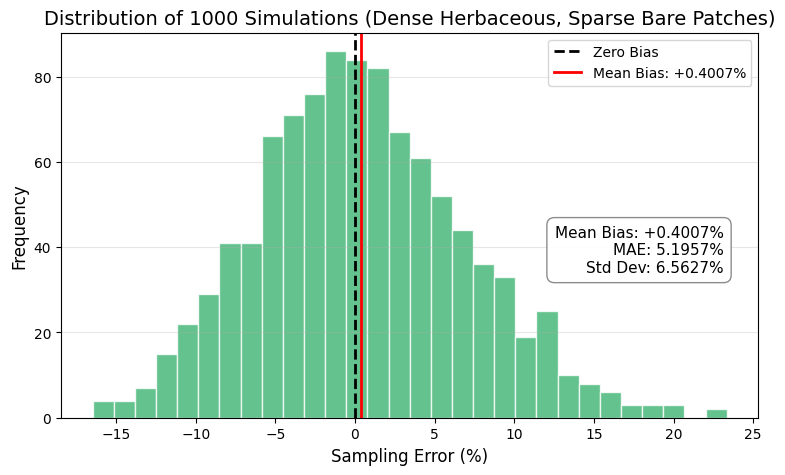

--- INVERTED STATISTICAL SUMMARY ---
Mean Bias: +0.4007%
Mean Absolute Error: 5.1957%
Standard Deviation: 6.5627%


In [ ]:

# ==========================================
# BLOCK 4: Inverted Headless Validation
# ==========================================
def run_inverted_thousand_simulations(num_iterations=1000, plot_radius=55, hub_radius=5):
    """Runs the inverted logic headless for 1000 iterations to verify accuracy."""
    plot_circle = Point(0, 0).buffer(plot_radius)
    spokes = get_nri_spokes(hub_radius, plot_radius)
    total_transect_length = 3 * (plot_radius - hub_radius)

    errors = []

    print(f"Crunching {num_iterations} inverted simulations... please wait.")

    for i in range(num_iterations):
        # 1. Generate bare ground patches
        patches = generate_random_shrubs(60, plot_radius)
        patch_union = unary_union(patches)

        # 2. Calculate True Bare Ground (INVERTED LOGIC)
        patches_in_plot = patch_union.intersection(plot_circle)
        true_bg_pct = (patches_in_plot.area / plot_circle.area) * 100

        # 3. Calculate Sampled Bare Ground (INVERTED LOGIC)
        total_intercept = 0
        for spoke in spokes:
            intersection = spoke.intersection(patch_union)
            total_intercept += intersection.length

        sampled_bg_pct = (total_intercept / total_transect_length) * 100

        # 4. Record Error
        errors.append(sampled_bg_pct - true_bg_pct)

    # --- Statistics ---
    mean_error = np.mean(errors)
    std_dev = np.std(errors)
    mae = np.mean(np.abs(errors))

    # --- Visualize Results ---
    plt.figure(figsize=(9, 5))
    # Using a brown/tan color theme to represent the dirt patches
    plt.hist(errors, bins=30, color='mediumseagreen', edgecolor='white', alpha=0.8)
    plt.axvline(0, color='black', linestyle='--', linewidth=2, label='Zero Bias')
    plt.axvline(mean_error, color='red', linewidth=2, label=f'Mean Bias: {mean_error:+.4f}%')

    plt.title(f"Distribution of {num_iterations} Simulations (Dense Herbaceous, Sparse Bare Patches)", fontsize=14)
    plt.xlabel("Sampling Error (%)", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(axis='y', alpha=0.3)

    stats_text = (
        f"Mean Bias: {mean_error:+.4f}%\n"
        f"MAE: {mae:.4f}%\n"
        f"Std Dev: {std_dev:.4f}%"
    )
    plt.gca().text(0.95, 0.50, stats_text, transform=plt.gca().transAxes,
                   fontsize=11, verticalalignment='top', horizontalalignment='right',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9))

    from IPython.display import clear_output
    clear_output(wait=True)
    plt.show()

    print("--- INVERTED STATISTICAL SUMMARY ---")
    print(f"Mean Bias: {mean_error:+.4f}%")
    print(f"Mean Absolute Error: {mae:.4f}%")
    print(f"Standard Deviation: {std_dev:.4f}%")

run_inverted_thousand_simulations(1000)
